# Car Price Prediction

In [42]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from datetime import datetime

# Hyperparameters

In [43]:
RANDOM_STATE = 42

RF_PARAMS = {
    "n_estimators": 408,
    "max_depth": 12,
    "min_samples_leaf": 3,
    "min_samples_split": 7,
    "random_state": RANDOM_STATE
}

XGB_PARAMS = {
    "n_estimators": 388,
    "learning_rate": 0.0165,
    "max_depth": 8,
    "subsample": 0.7218,
    "colsample_bytree": 0.8430,
    "gamma": 0.0853,
    "reg_alpha": 0.9656,
    "reg_lambda": 0.8084,
    "tree_method": "hist",
    "random_state": RANDOM_STATE
}

# Load Data

In [44]:
train_df = pd.read_csv("content/train_data.csv")
test_df = pd.read_csv("content/test_data.csv")
train_df['source'] = 'train'
test_df['source'] = 'test'
data = pd.concat([train_df, test_df], ignore_index=True)

# Initial Cleaning

In [45]:
cols_to_drop = ['ID', 'Doors', 'Wheel', 'Color']
data.drop(columns=cols_to_drop, inplace=True)

def fix_encoding(text):
    try:
        return text.encode('latin1').decode('utf-8')
    except:
        return text

data['Model'] = data['Model'].astype(str).apply(fix_encoding)

valid_fuel_types = [
    'Petrol', 'Diesel', 'Hybrid', 'LPG', 'CNG', 'Plug-in Hybrid', 'Hydrogen', 'Electric'
]
data = data[data['Fuel type'].isin(valid_fuel_types)]

# Clean Numeric Columns

In [46]:
data['Levy'] = data['Levy'].replace('-', np.nan)
data['Levy'] = pd.to_numeric(data['Levy'], errors='coerce')
data['Levy'] = data['Levy'].fillna(data['Levy'].median())

data['Mileage'] = data['Mileage'].str.replace(' km', '').str.replace(',', '').astype(float)
median_mileage = data.loc[data['Mileage'] > 0, 'Mileage'].median()
data['Mileage'] = data['Mileage'].apply(lambda x: median_mileage if pd.isna(x) or x == 0 else x)

data['Engine volume'] = data['Engine volume'].str.extract(r'(\d+\.?\d*)').astype(float)
data['Cylinders'] = data['Cylinders'].str.extract(r'(\d+)').astype(float)
data['Prod. year'] = pd.to_numeric(data['Prod. year'], errors='coerce')
data['Leather interior'] = data['Leather interior'].map({'Yes': 1, 'No': 0})

# Fill Missing Values & Fix Model-Manufacturer Consistency

In [47]:
for col in data.columns:
    if data[col].dtype in [np.float64, np.int64]:
        data[col] = data[col].fillna(data[col].median())
    else:
        data[col] = data[col].fillna(data[col].mode()[0])

manufacturer_model_df = data[['Manufacturer', 'Model']].dropna()

manufacturer_model_dict = (
    manufacturer_model_df.groupby('Manufacturer')['Model']
    .apply(lambda x: set(x.dropna()))
    .to_dict()
)

model_manufacturer_dict = {}
for manu, models in manufacturer_model_dict.items():
    for model in models:
        model_manufacturer_dict.setdefault(model, set()).add(manu)

def fill_manufacturer(row):
    if pd.isna(row['Manufacturer']) and row['Model'] in model_manufacturer_dict:
        possible = model_manufacturer_dict[row['Model']]
        if len(possible) == 1:
            return list(possible)[0]
    return row['Manufacturer']

def fill_model_strict(row):
    if pd.isna(row['Model']) and row['Manufacturer'] in manufacturer_model_dict:
        possible = manufacturer_model_dict[row['Manufacturer']]
        if len(possible) == 1:
            return list(possible)[0]
    return row['Model']

data['Manufacturer'] = data.apply(fill_manufacturer, axis=1)
data['Model'] = data.apply(fill_model_strict, axis=1)

most_common_model_by_manufacturer = (
    manufacturer_model_df.groupby('Manufacturer')['Model']
    .agg(lambda x: x.value_counts().idxmax())
    .to_dict()
)

def fill_model_fallback(row):
    if pd.isna(row['Model']) and row['Manufacturer'] in most_common_model_by_manufacturer:
        return most_common_model_by_manufacturer[row['Manufacturer']]
    return row['Model']

data['Model'] = data.apply(fill_model_fallback, axis=1)
data = data[data['Manufacturer'].notna()]

data = data[data['Price'].notna()].copy()
data = data[data['Price'] >= 2000]
data = data[data['Price'] <= data['Price'].quantile(0.99)]

for col in ['Mileage', 'Levy', 'Engine volume', 'Cylinders', 'Airbags']:
    upper_limit = data[col].quantile(0.995)
    data[col] = np.where(data[col] > upper_limit, upper_limit, data[col])

# Visulaization

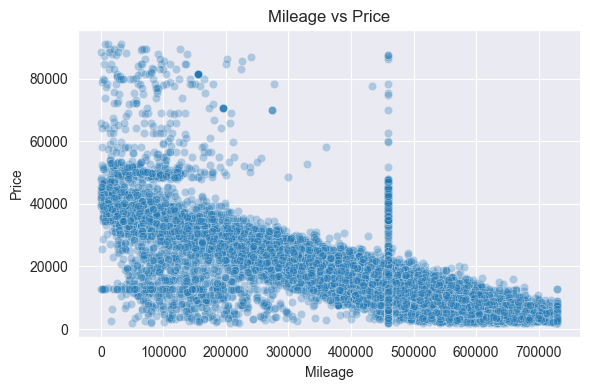

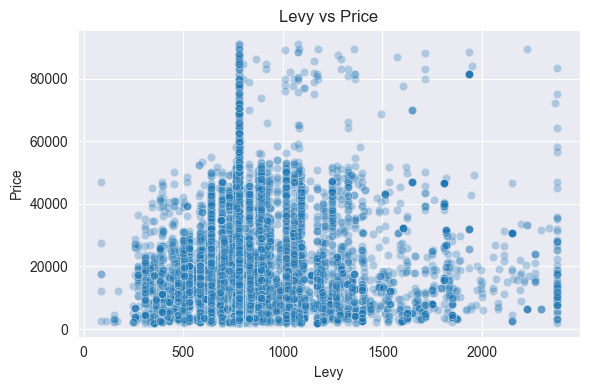

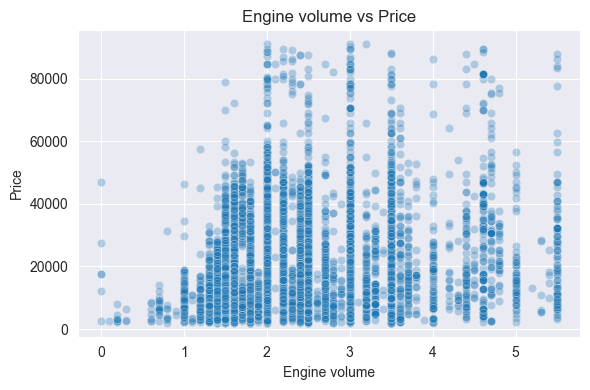

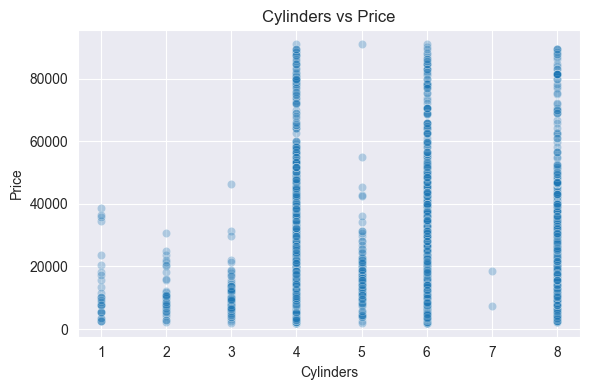

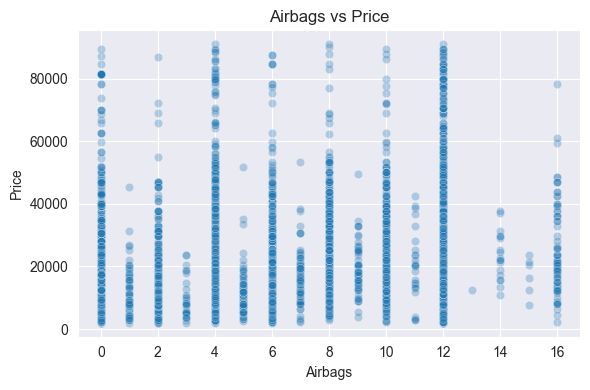

In [49]:
num_features = ['Mileage', 'Levy', 'Engine volume', 'Cylinders', 'Airbags']

for feature in num_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=data[feature], y=data['Price'], alpha=0.3)
    plt.title(f'{feature} vs Price')
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.tight_layout()
    plt.show()

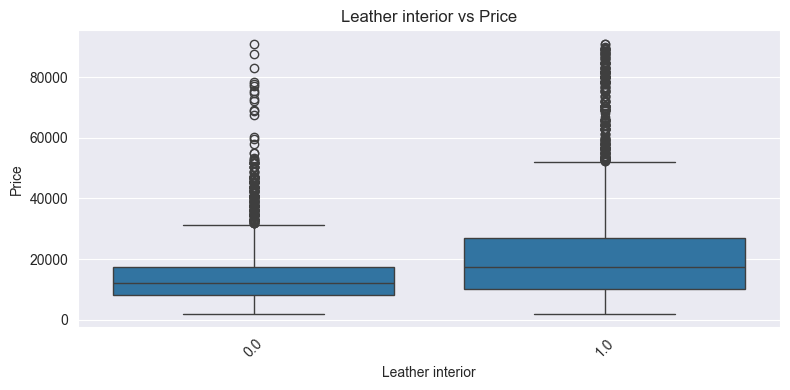

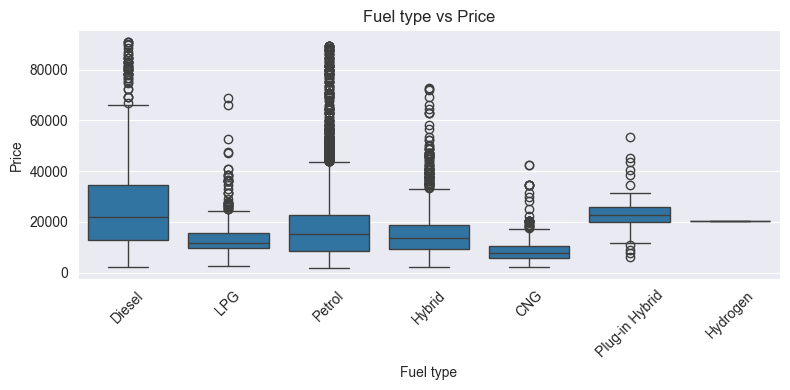

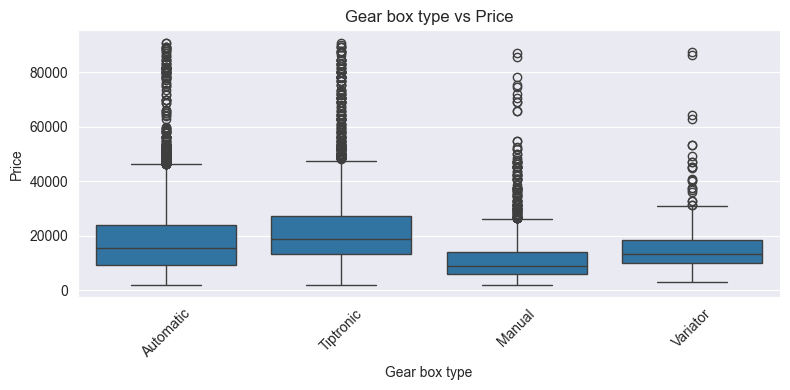

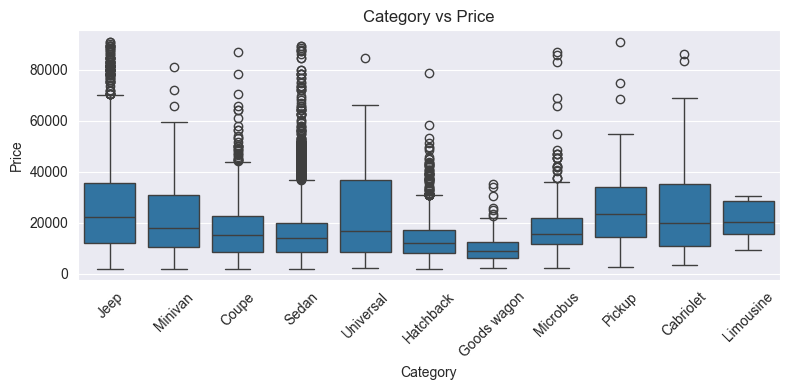

In [50]:
cat_features = ['Leather interior', 'Fuel type', 'Gear box type', 'Category']

for feature in cat_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[feature], y=data['Price'])
    plt.title(f'{feature} vs Price')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Feature Engineering

In [51]:
current_year = datetime.now().year
data['Car_Age'] = current_year - data['Prod. year']
data = data.drop(columns=['Prod. year'])

one_hot_cols = ['Category', 'Fuel type', 'Gear box type', 'Drive wheels']
for col in one_hot_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

data = pd.get_dummies(data, columns=one_hot_cols, drop_first=True)

for col in ['Manufacturer', 'Model']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

num_cols = ['Levy', 'Mileage', 'Engine volume', 'Cylinders', 'Airbags', 'Car_Age']
scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

# Modeling Setup

In [52]:
train_data = data[data['source'] == 'train'].drop(columns=['source'])
test_data = data[data['source'] == 'test'].drop(columns=['source'])

X_train = train_data.drop(columns=['Price'])
y_train = train_data['Price']
X_test = test_data.drop(columns=['Price']) if 'Price' in test_data.columns else test_data
y_test = test_data['Price'] if 'Price' in test_data.columns else None

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

y_train_log = np.log1p(y_train_split)
y_val_log = np.log1p(y_val_split)

# Train Models

In [53]:
results = {}
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train_split)
X_val_poly = poly.transform(X_val_split)

ridge = Ridge(alpha=1000.0)
ridge.fit(X_train_poly, y_train_log)
pred_log_poly = ridge.predict(X_val_poly)
pred_ridge = np.expm1(pred_log_poly)
results['Ridge Regression'] = {
    'RMSE': np.sqrt(mean_squared_error(y_val_split, pred_ridge)),
    'R2': r2_score(y_val_split, pred_ridge)
}

knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train_split, y_train_split)
pred_knn = knn.predict(X_val_split)
results['KNN'] = {
    'RMSE': np.sqrt(mean_squared_error(y_val_split, pred_knn)),
    'R2': r2_score(y_val_split, pred_knn)
}

rf = RandomForestRegressor(**RF_PARAMS)
rf.fit(X_train_split, y_train_split)
pred_rf = rf.predict(X_val_split)
results['Random Forest'] = {
    'RMSE': np.sqrt(mean_squared_error(y_val_split, pred_rf)),
    'R2': r2_score(y_val_split, pred_rf)
}

xgb = XGBRegressor(**XGB_PARAMS)
xgb.fit(X_train_split, y_train_split)
pred_xgb = xgb.predict(X_val_split)
results['XGBoost'] = {
    'RMSE': np.sqrt(mean_squared_error(y_val_split, pred_xgb)),
    'R2': r2_score(y_val_split, pred_xgb)
}

for model, metrics in results.items():
    print(f"{model}:\n  RMSE: {metrics['RMSE']:.2f}\n  R2: {metrics['R2']:.2f}\n")

/Users/egensolve/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/egensolve/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/egensolve/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/egensolve/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/egensolve/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/egensolve/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: i

Ridge Regression:
  RMSE: 7602.95
  R2: 0.66

KNN:
  RMSE: 7435.94
  R2: 0.67

Random Forest:
  RMSE: 5115.78
  R2: 0.85

XGBoost:
  RMSE: 4920.17
  R2: 0.86



# Evaluate on Test Set

In [54]:
def evaluate_on_test(model, name, test_data, log_transformed=False, poly=None):
    if 'Price' in test_data.columns:
        X_test = test_data.drop(columns=['Price'])
        y_test = test_data['Price']
    else:
        X_test = test_data
        y_test = None

    if poly is not None:
        X_test = poly.transform(X_test)

    test_pred = model.predict(X_test)
    if log_transformed:
        test_pred = np.expm1(test_pred)

    print(f"Performance on Test Data ({name}):")
    if y_test is not None:
        test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
        test_r2 = r2_score(y_test, test_pred)
        print(f"  Test RMSE: {test_rmse:.2f}, R²: {test_r2:.2f}")
    else:
        print("  Predictions made on the test data (no target variable available for evaluation).")
    print("-" * 40)

evaluate_on_test(ridge, "Ridge Regression", test_data, log_transformed=True, poly=poly)
evaluate_on_test(knn, "KNN", test_data)
evaluate_on_test(rf, "Random Forest", test_data)
evaluate_on_test(xgb, "XGBoost", test_data)

Performance on Test Data (Ridge Regression):
  Test RMSE: 7220.17, R²: 0.68
----------------------------------------
Performance on Test Data (KNN):
  Test RMSE: 6961.85, R²: 0.70
----------------------------------------
Performance on Test Data (Random Forest):
  Test RMSE: 5328.68, R²: 0.82
----------------------------------------
Performance on Test Data (XGBoost):
  Test RMSE: 4925.95, R²: 0.85
----------------------------------------


/Users/egensolve/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/egensolve/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/egensolve/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


# Visualizations

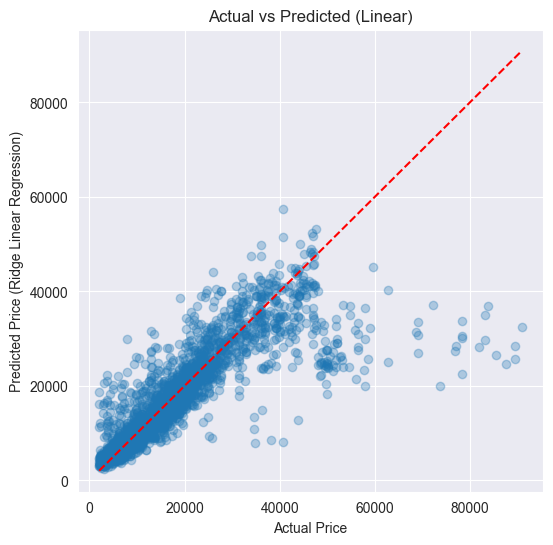

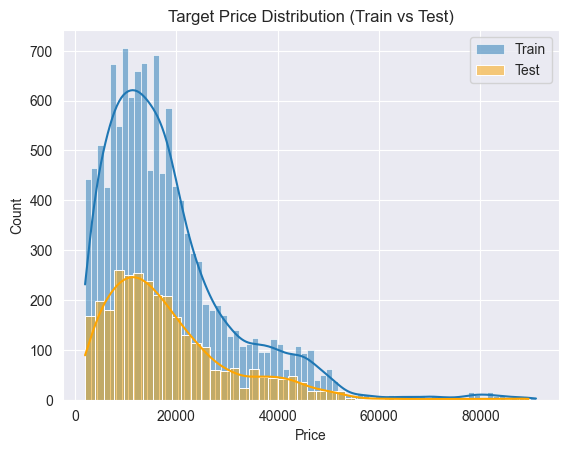

In [55]:
plt.figure(figsize=(6, 6))
plt.scatter(y_val_split, pred_ridge, alpha=0.3)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price (Ridge Linear Regression)')
plt.title('Actual vs Predicted (Linear)')
plt.plot([y_val_split.min(), y_val_split.max()], [y_val_split.min(), y_val_split.max()], 'r--')
plt.show()

sns.histplot(y_train, label='Train', kde=True)
sns.histplot(y_test, label='Test', kde=True, color='orange')
plt.title("Target Price Distribution (Train vs Test)")
plt.legend()
plt.show()